In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
# Dark Mode Plots
plt.style.use('dark_background')
import corner
import ast

In [13]:
# Make the corner plot for the MCMC results
system_name = 'B2045'
model_ver = 'sie'
mcmc_samples_path = f'../{system_name}/mcmc/{model_ver}_mcmc.dat'
samples = pd.read_csv(mcmc_samples_path, delim_whitespace=True, header=None, names=['chi2', 'z_lens', 'vel_disp', 'x', 'y', 'ellip', 'pa' ])


In [14]:
samples

,chi2,z_lens,vel_disp,x,y,ellip,pa
0,1.793667,1.130800,440.8198,0.715648,1.147360,0.596353,32.08993
1,1.878984,1.378610,701.5667,0.715599,1.146821,0.596337,32.08992
2,1.848615,1.244973,522.7831,0.715601,1.147081,0.596698,32.08985
3,4.543195,1.425163,817.5033,0.715510,1.147413,0.596519,32.08988
4,4.636269,1.378368,699.9464,0.715580,1.147176,0.596834,32.08994
5,4.062303,1.465369,984.5359,0.715594,1.146135,0.596943,32.08989
6,3.711101,1.461443,961.1241,0.715555,1.146324,0.597055,32.09007
7,4.324482,1.286125,562.9770,0.715567,1.145552,0.597223,32.09004
8,3.049971,0.968201,366.1847,0.715527,1.145064,0.597035,32.09002
9,2.221014,0.897517,342.8628,0.715511,1.145272,0.596799,32.08999


In [15]:
masked_samples = samples.drop(columns=['chi2']).to_numpy()

In [16]:
# # Masked Samples with no accept column
# masked_samples = samples[samples['accept'] == 'accept'].copy()
# masked_samples = masked_samples.drop(columns=['accept', 'chi2']).to_numpy()
# masked_samples

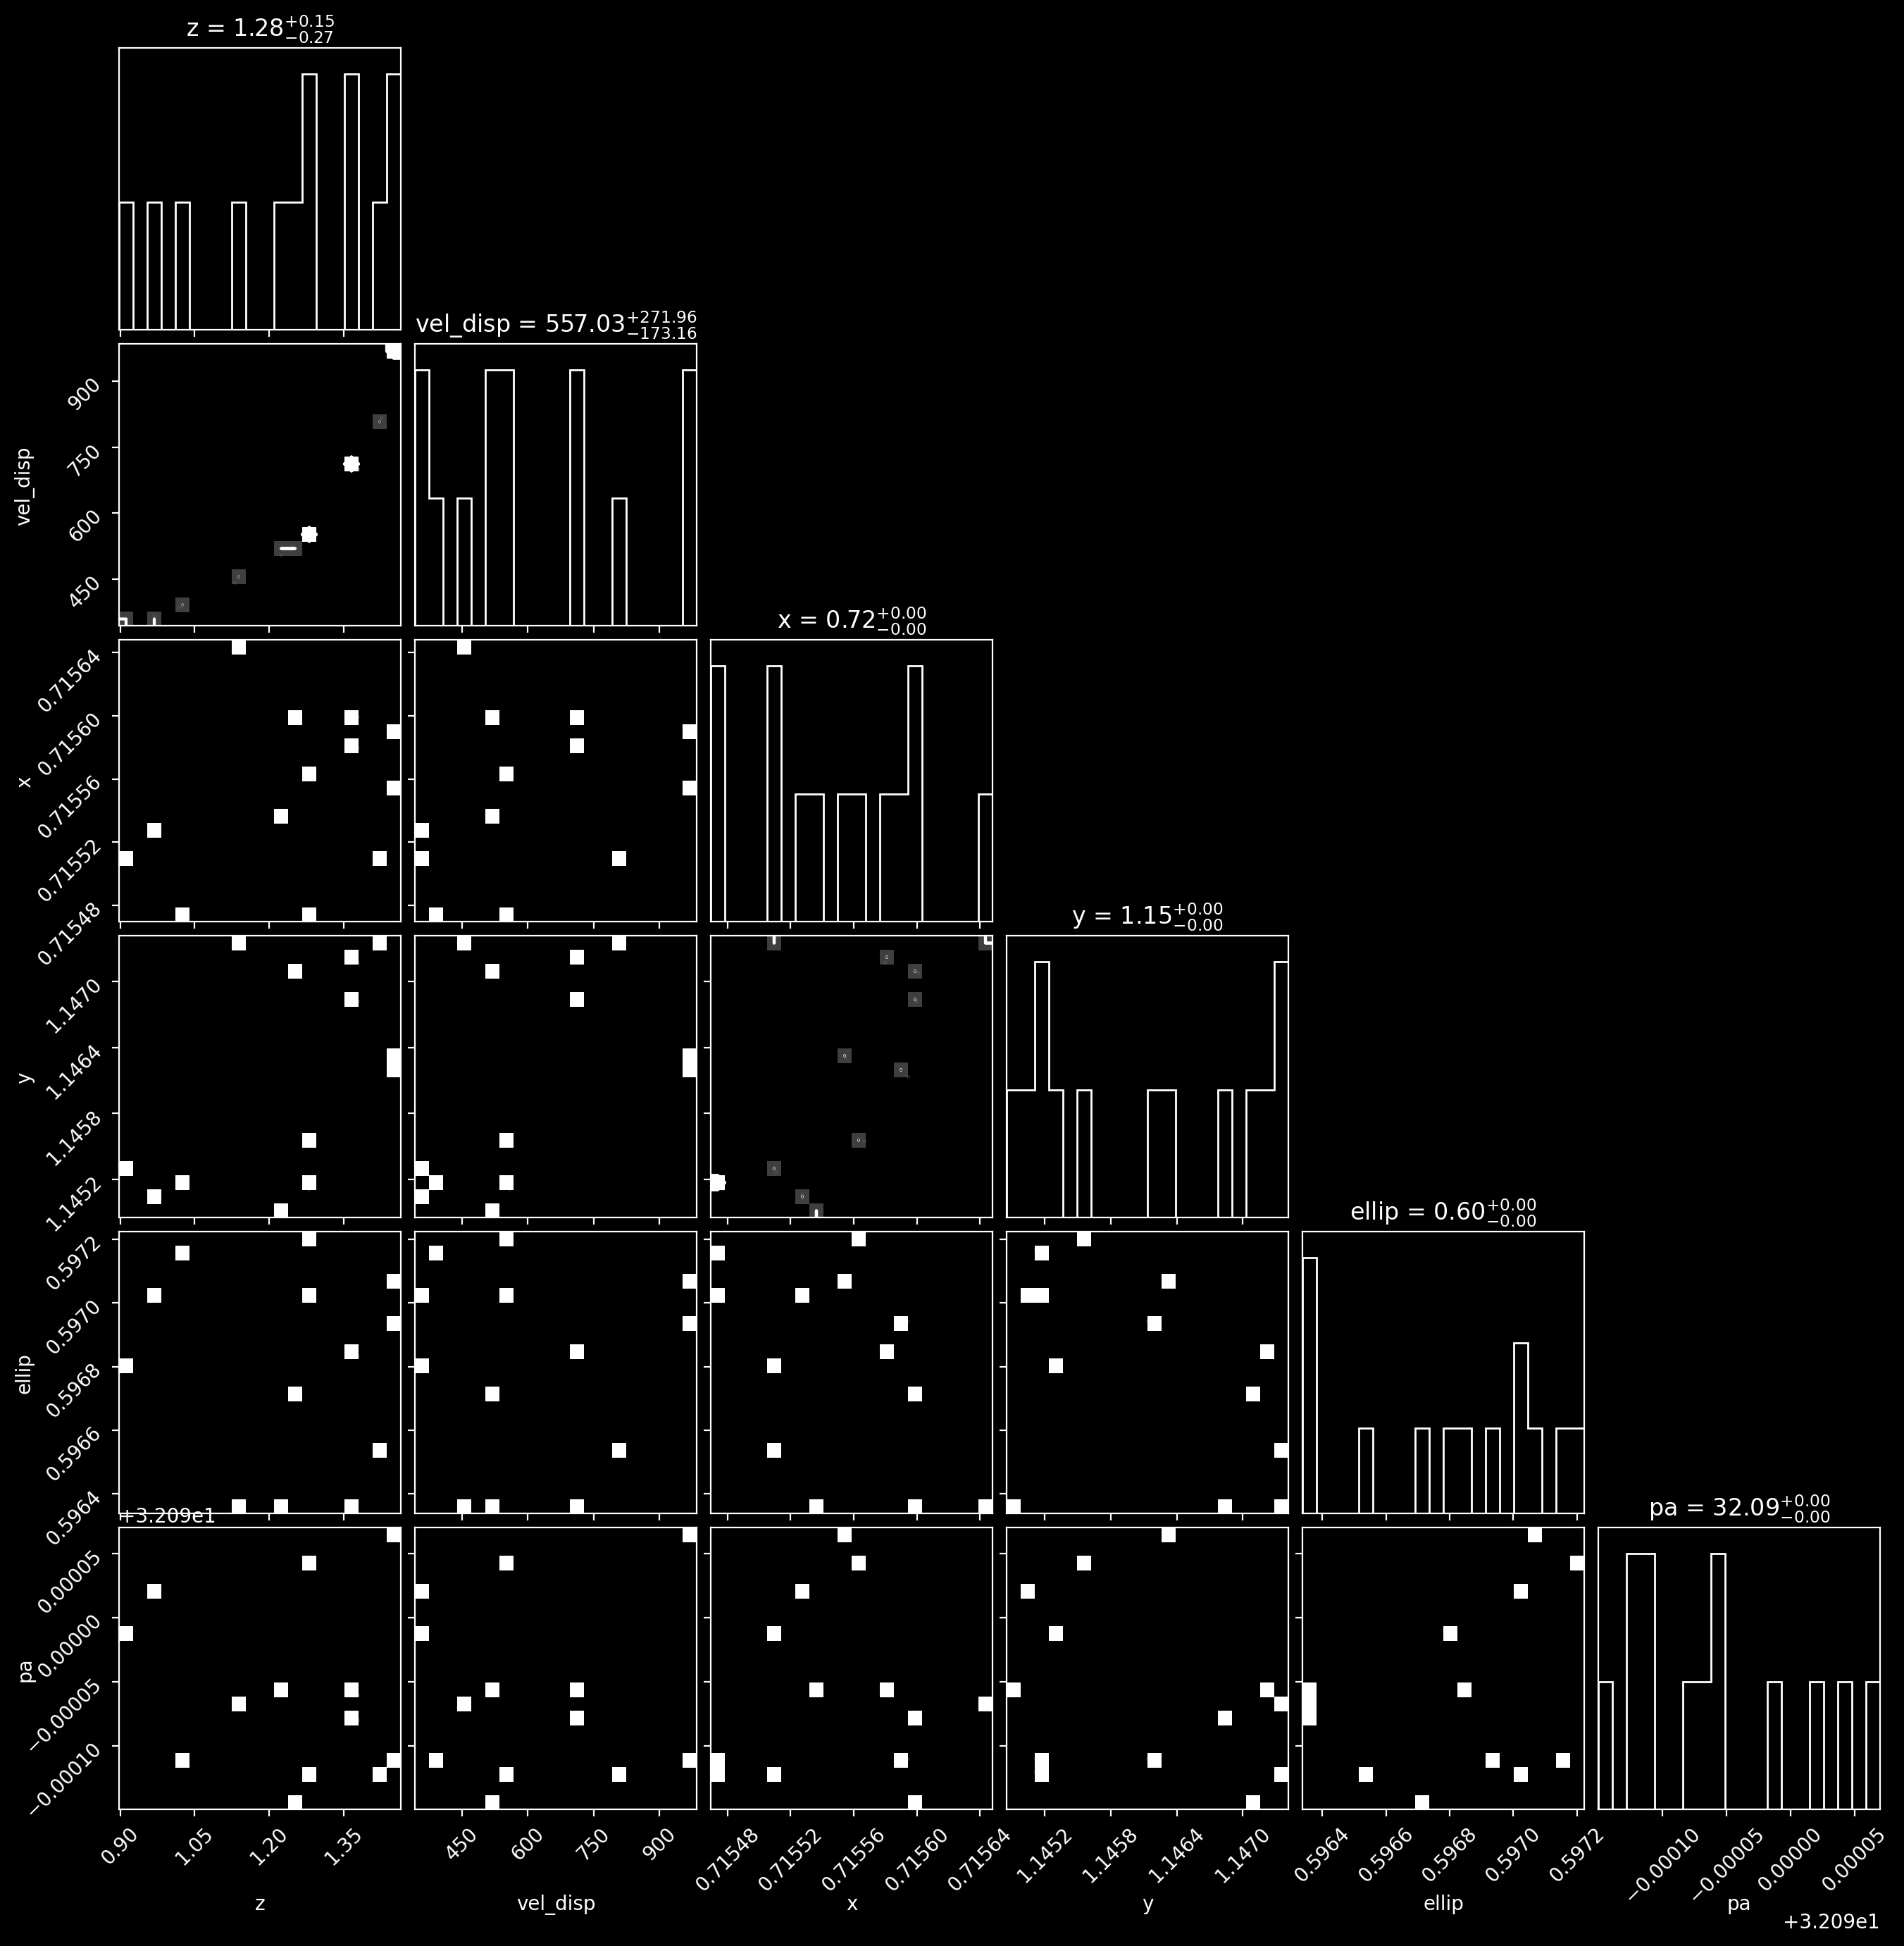

In [17]:
# Remove the first column when loading the samples, as it is the accepted/rejected column
labels = ['z', 'vel_disp', 'x', 'y', 'ellip', 'pa']
fig = corner.corner(masked_samples, labels=labels, show_titles=True)
plt.savefig(f'../{system_name}/mcmc/{model_ver}_corner.png')